# Indiana Bosonic Code - DMANH

In [36]:
from jaqalpaq import run
from jaqalpaq import emulator
from jaqalpaq.run import run_jaqal_file, run_jaqal_string, run_jaqal_batch, run_jaqal_circuit, frontend

from jaqalpaq.emulator.unitary import UnitarySerializedEmulator
emulator_backend = UnitarySerializedEmulator()

#from Experiment import Experiment
import numpy as np
import csv
from datetime import datetime, date, time, timezone
from pytz import timezone
from collections import OrderedDict
import pytz
from scipy.special import jn_zeros
import math
import matplotlib.pyplot as plt
import pickle as pkl
from jaqalpaq.parser import parse_jaqal_string
from pprint import pprint

def timestamp_generate():
    mountain = timezone('US/Mountain')
    timestamp_utc = datetime.utcnow()
    timestamp_local = timestamp_utc.astimezone(mountain)
    return(timestamp_utc, timestamp_local)

def int_to_base(n, b):
    if n == 0:
        return "0"
    digits = []
    is_negative = n < 0
    n = abs(n)
    while n:
        digits.append(int(n % b))
        n //= b
    if is_negative:
        digits.append("-")
    return ''.join(str(x) if x < 10 else chr(55 + x) for x in reversed(digits))



In [55]:
#Can import a file here with the angles in it, so angles can be called automatically. 

nq = 2
repeats = 1000
im_beta_list = np.linspace(-0.4, 0.4, 5).tolist()
override_dict = {"__repeats__": repeats,
                 "imBeta": im_beta_list}


import os
import ast

working_dir = os.getcwd()
recursive_dir = working_dir
for ii in range(5):
    temp_dir = os.path.dirname(recursive_dir)
    recursive_dir = temp_dir
file_path = recursive_dir


#with open(os.path.join(file_path,'Indiana_QSD_Dict1.txt'), 'r') as file:
#    string_data = file.read()
#angles = ast.literal_eval(string_data)

# ok, making this part up now as it doesn't exist, so how 
# exactly this is called in should be modified to match the actual file
angle = [[0.18512000000000001, 0, 0.79999999999999982],
        [0.18128949140032261, 0.03746377861097782, 0.79999999999999982],
        [0.16995648759926149, 0.073377153957632377, 0.79999999999999982]]



In [ ]:
class JaqalGenerator:
    header = (
        "from Calibration_PulseDefinitions.QubitBosonPulses usepulses *\n"
        "let reBeta -0.20000000000000001\n"
        "let imBeta 0\n\n"
        # "let imMeas 1\n\n"

        "register q[2]\n\n"
    )

    subcircuit_header = (
        "// ******************* //\n"
        "// Subcircuit with {subcirc_idx} Trotter steps\n"
        "prepare_all\n"
        "// Wavepacket preparation: |down>|0> -> |down>|x=-x_min> using zCD.\n"
        "zCD q[0] 1 1 0.89021208217480396 0\n\n"
    )

    subcircuit_step = (
        "// Evolution step {time_step} \n"
        "xCD q[0] 1 1 {m_reBeta:.17f} {m_imBeta:.17f}\n"
        "Rz q[0] {phi:.17f}\n"
        "xCD q[0] 1 1 {reBeta:.17f} {imBeta:.17f}\n"
        "xCD q[0] 1 1 {reBeta:.17f} {imBeta:.17f}\n"
        "Rz q[0] {phi:.17f}\n"
        "xCD q[0] 1 1 {m_reBeta:.17f} {m_imBeta:.17f}\n"
    )
    
    subcircuit_footer = (
        "// Characteristic-function readout.\n"
        # "loop imMeas {\n"
        "R q[1] 0 1.5707963267948966\n"
        # "}\n"
        "xCD q[1] 1 1 reBeta imBeta\n"
        "measure_all\n"
        "// ******************* //\n\n\n"
    )

    @classmethod
    def generate(self, angle_data: list[list[float]]) -> str:
        trotter_steps = len(angle_data)
        jaqal_string = self.header
        for ii in range(trotter_steps):
            jaqal_string += self._gen_subcircuit(ii, angle_data)
        return jaqal_string
    
    @classmethod
    def _gen_subcircuit(self, trotter_steps: int, angle_data: list[list[float]]) -> str:
        subcircuit = self.subcircuit_header.format(subcirc_idx=trotter_steps)
        for ii in range(trotter_steps):
            subcircuit += self.subcircuit_step.format(time_step=ii + 1,
                                                   reBeta=angle_data[ii][0],
                                                   imBeta=angle_data[ii][1],
                                                   m_reBeta=-angle_data[ii][0],
                                                   m_imBeta=-angle_data[ii][1],
                                                   phi=angle_data[ii][2])
        subcircuit += self.subcircuit_footer
        return subcircuit
    

In [57]:
# The for loop was removed because batching has been moved to overrides (also some of the names have changed, sorry).

jaqal_string = JaqalGenerator.generate(angle_data=angle)

print(jaqal_string)

from Calibration_PulseDefinitions.QubitBosonPulses usepulses *
let reBeta -0.20000000000000001
let imBeta 0

register q[2]

// ******************* //
// Subcircuit with 0 Trotter steps
prepare_all
// Wavepacket preparation: |down>|0> -> |down>|x=-x_min> using zCD.
zCD q[0] 1 1 0.89021208217480396 0

// Characteristic-function readout.
R q[1] 0 1.5707963267948966
xCD q[1] 1 1 reBeta imBeta
measure_all
// ******************* //


// ******************* //
// Subcircuit with 1 Trotter steps
prepare_all
// Wavepacket preparation: |down>|0> -> |down>|x=-x_min> using zCD.
zCD q[0] 1 1 0.89021208217480396 0

// Evolution step 1 
xCD q[0] 1 1 -0.18512000000000001 0.00000000000000000
Rz q[0] 0.79999999999999982
xCD q[0] 1 1 0.18512000000000001 0.00000000000000000
xCD q[0] 1 1 0.18512000000000001 0.00000000000000000
Rz q[0] 0.79999999999999982
xCD q[0] 1 1 -0.18512000000000001 0.00000000000000000
// Characteristic-function readout.
R q[1] 0 1.5707963267948966
xCD q[1] 1 1 reBeta imBeta
measure_a

In [6]:
results = run.run_jaqal_string(jaqal_string, overrides = override_dict)

# print(results)

In [ ]:
def exp_z(prob): #Postselect the results on the 
    """Expectation value of Z"""
    #probe qubit's state probabilities
    if prob[0] + prob[2] == 0:
        state0 = 0
        state1 = 0
    else:
        state0 = prob[0]/(prob[0]+prob[2])
        state1 = prob[2]/(prob[0]+prob[2])
    
    return state0 - state1

In [ ]:
#Extract the data from the results object
#This extracts the axis data

imMeas = np.empty((len(im_beta_list), len(angle), 2 ** nq))
expZ_imMeas = np.empty((len(im_beta_list), len(angle)))

print(len(results.by_subbatch[0].by_subcircuit[0].probability_by_int[:,0]))

for ii in range(len(im_beta_list)):
    for jj in range(len(angle)):
        imMeas[ii, jj, :] = results.by_subbatch[ii].by_subcircuit[jj].probability_by_int[:,0]
        expZ_imMeas[ii, jj] = exp_z(imMeas[ii, jj])
print(imMeas[0, 0])
print(expZ_imMeas)
np.save('expZ_imMeas',expZ_imMeas) 

#If you want to have the outputs available in a text format, the save functions below are useful. 
# #Save all probabilities
# np.save('prob_imMeas',imMeas)

# #Save beta ranges
# np.save('ImBetas',im_values)


4
[0.5 0.  0.5 0. ]
[[2.22044605e-16 2.22044605e-16 2.22044605e-16]
 [2.22044605e-16 2.22044605e-16 2.22044605e-16]
 [2.22044605e-16 2.22044605e-16 2.22044605e-16]
 [2.22044605e-16 2.22044605e-16 2.22044605e-16]
 [2.22044605e-16 2.22044605e-16 2.22044605e-16]]


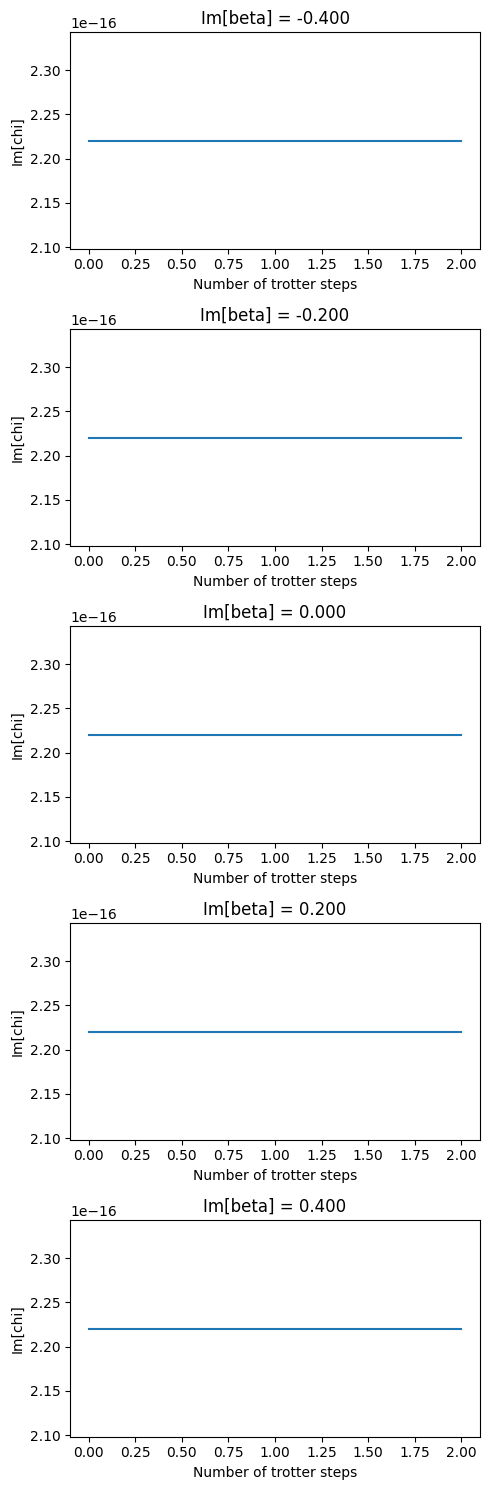

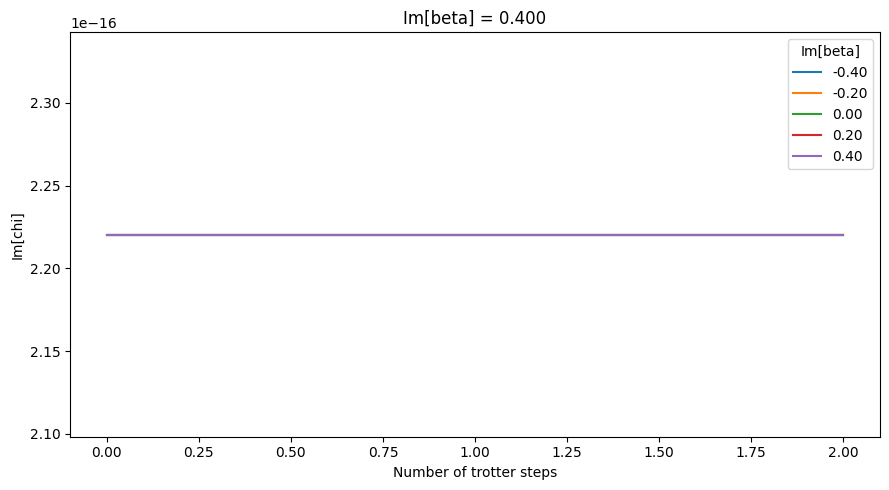

In [32]:
fig, axs = plt.subplots(3,2, figsize=(14, 14))
fig.subplots_adjust(hspace = .15, wspace=.1)        
axes = axs.ravel()

for ii, beta in enumerate(im_beta_list):
    axes[ii].plot(np.arange(len(angle)), expZ_imMeas[ii, :], label=f"{beta:.2f}")
    axes[ii].set_title(f"Im[beta] = {beta:.3f}")
    axes[ii].set_xlabel("Number of trotter steps")
    axes[ii].set_ylabel("Im[chi]")
fig.tight_layout()

lastplot = len(im_beta_list)

for  ii, beta in enumerate(im_beta_list):
    axes[lastplot].plot(np.arange(len(angle)), expZ_imMeas[ii, :], label=f"{beta:.2f}")
axes[lastplot].set_title('All Im[beta]')
axes[lastplot].set_xlabel("Number of trotter steps")
axes[lastplot].set_ylabel("Im[chi]")
axes[lastplot].legend(title="Im[beta]")
fig.tight_layout()